In [1]:
import datetime
import pathlib
import json

import colorcet as cc
import datashader as ds
import pandas as pd
import numpy as np
import xarray as xr
import seaborn as sns
import tensorflow as tf

import plotly
import plotly.express as px
import plotly.offline as pyo
import plotly.io as pio
import plotly.graph_objs as go
from plotly.subplots import make_subplots

import matplotlib.pyplot as plt

from html2image import Html2Image

from scipy.stats import pearsonr

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from dateutil.relativedelta import relativedelta

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
src_path = pathlib.Path('~').expanduser().resolve() / 'data/swan-uncertainties'
write_dir = pathlib.Path("/gpfs/work2/0/prjs1027/guus/data")
bathymetry_path = src_path / 'swan-ns-j22_6-v1a_adjust.bot'
valid_mask = np.load(src_path / "run3/valid-mask.npy")

In [4]:
tfrecord_dir = pathlib.Path('/gpfs/work2/0/prjs1027/tfrecords/run2')
output_variables = ["hs", "theta0", "tmm10", "tps", "hswe"]
input_variables = ["xwnd", "ywnd", "wl", "xcur", "ycur"]
boundary_variables = ["hs_bnd", "hswe_bnd", "tmm10_bnd", "theta0_bnd"]

vmins = [0, -1, -1, 0, 0, 0]
variable_fields = input_variables + output_variables + boundary_variables

min_max_values = xr.open_dataset(src_path / "run3/min-max-values/min-max-values-all.nc")

for bnd_var in boundary_variables:
    min_max_values[bnd_var] = min_max_values[bnd_var.split("_")[0]]

min_max_values["theta0_x"] = xr.DataArray(np.array([-1, 1.]), dims='index')
min_max_values["theta0_y"] = xr.DataArray(np.array([-1, 1.]), dims='index')

boundary_variables = ["Hm0", "Tmm10", "HE10", "meanD"]
conversion_dict = {"Hm0": "hs", "HE10": "hswe", "Tmm10": "tmm10", "meanD": "theta0"}

In [5]:
def load_ascii_bathy(input_grid_file_path, lon_start, lat_start, lon_step, lat_step):
    """
    Loads bathymetry and grid from ascii file (GEBCO)
 
    Args:
        input_grid_file_path (str): path to grid file
        lon_start: start longitude
        lat_start:
    Returns:
        lon, lat, bottom_data (np.array): 2D arrays with lon and lat values
        and bottom data
 
    Example usage:
        lon_start, lat_start, lon_step, lat_step = -3.000000, 51.500000, 0.500000, 0.500000
        lon_bathy, lat_bathy, bottom_data = input_loader.load_bathy(extra_path + "depth.GRD", lon_start, lat_start, lon_step, lat_step)
 
    """
    # Read the bottom grid data from the ASCII file
    bottom_data = np.loadtxt(input_grid_file_path)
 
    # Transpose the data to match the provided organization (latitude columns, longitude rows)
    bottom_data = bottom_data.T
 
    # Replace -999 with NaN
    bottom_data[bottom_data == -999] = np.nan
 
    lons = np.arange(lon_start, lon_start + len(bottom_data[0]) * lon_step, lon_step)
    lats = np.arange(lat_start, lat_start + len(bottom_data) * lat_step, lat_step)
 
    # Create a meshgrid from the coordinates
    lon, lat = np.meshgrid(lons, lats)
 
    return lon, lat, bottom_data

bathymetry = load_ascii_bathy(bathymetry_path, -12, 48, 0.05, 1/30)[2]

In [6]:
def normalize(data, var):
    data = (data - min_max_values[var].values[0]) / (min_max_values[var].values[1] - min_max_values[var].values[0])
    return data

def denormalize(data, var):
    data = data * (min_max_values[var].values[1] - min_max_values[var].values[0]) + min_max_values[var].values[0]
    return data

In [7]:
learning_rate = 1e-4
n_epochs = 100
batch_size = 16
steps_per_execution = 1

model_version = "turbo_swan_v0002"

src_dir = pathlib.Path().resolve().parent
model_dir = src_dir / f"models/{model_version}"
model_dir.mkdir(exist_ok=True, parents=True)

figure_dir = model_dir / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)

raster_shape = (481, 421, 2)
widths = [16, 32, 64, 128, 256, 256]
block_depth = 3

In [8]:
def masked_loss(mask):
    def loss(y_true, y_pred):
        mask_expanded = tf.expand_dims(mask, axis=0)
        mask_tiled = tf.tile(mask_expanded, [tf.shape(y_true)[0], 1, 1])

        masked_true = tf.boolean_mask(y_true, mask_tiled)
        masked_pred = tf.boolean_mask(y_pred, mask_tiled)

        theta0_true = denormalize(masked_true[..., 1], var="theta0")
        theta0_pred = denormalize(masked_pred[..., 1], var="theta0")

        diff = masked_true - masked_pred
        diff_theta = circular_error(theta0_true, theta0_pred, to_rad=True)

         # Use TensorFlow operations to modify the tensor
        diff = tf.concat([diff[..., :1], tf.expand_dims(diff_theta, axis=-1), diff[..., 2:]], axis=-1)


        mse = K.mean(tf.square(diff))
        return mse
    return loss

In [9]:
model = tf.keras.models.load_model(model_dir / (model_version + '.h5'), custom_objects={'loss': masked_loss})
# model.summary()

2025-04-24 13:51:40.484870: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-04-24 13:51:40.484919: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2025-04-24 13:51:40.484924: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 24.00 GB
2025-04-24 13:51:40.484976: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-24 13:51:40.485010: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
val_ds = xr.load_dataset(src_path / 'validation_ens30.nc')
bc_ds = xr.open_dataset(src_path / "bnd.nc")

val_ds['wl'] = val_ds['ssh'] + bathymetry

In [11]:
with open(src_path / 'run3/train-val-test-split.json', 'r') as file:
    time_chunks = json.load(file)

for i in range(len(time_chunks['test_blocks'])):
    time_range = time_chunks['test_blocks'][i]
    time_chunks['test_blocks'][i] = slice(time_range[0], time_range[1])

In [12]:
test_ds = xr.concat([val_ds.sel(time=slice_) for slice_ in time_chunks['test_blocks']], dim='time')

In [13]:
times = test_ds.time.values

In [33]:
ens_30_pred = {var: [] for var in output_variables}
ens_30_true = {var: [] for var in output_variables}

for i in range(len(times)):
    input_data = {}
    boundary_data = {}
    for var in input_variables:
        data = val_ds[var].values

        shapes = data.shape
        
        field = np.empty((1, shapes[1], shapes[2], 2))
        field[..., 0] = val_ds[var].sel(time=times[i - 1]).values
        field[..., 1] = val_ds[var].sel(time=times[i]).values

        field = normalize(field, var)
        field[np.where(np.isnan(field))] = -9

        input_data[var] = field
        
    for var in boundary_variables:
        data = bc_ds[var].sel(time=times[i]).values[np.newaxis, ..., np.newaxis]
        data = normalize(data, conversion_dict[var])
        boundary_data[var] = data

    input_fields = np.concatenate([input_data[var] for var in input_variables], axis=-1)
    bc_data = np.concatenate([boundary_data[var] for var in boundary_variables], axis=-1)
    pred = model.predict((input_fields, bc_data))

    for j, var in enumerate(output_variables):
        prediction = denormalize(pred, var)[0, ..., j]
        if var == 'theta0':
            prediction = prediction % 360
        prediction = np.clip(prediction, a_min=0, a_max=None)
        prediction[valid_mask == 0] = np.nan
        
        truth = val_ds.sel(time=times[i])[var].values

        ens_30_pred[var].append(prediction)
        ens_30_true[var].append(truth)
    

1/1 [==============================] - 0s 20ms/step


In [15]:
ens_30_pred['hs'][0].shape

(481, 421)

In [15]:
dataset_dict = {}
for var, data in ens_30_pred.items():
    dataset_dict[f'{var}_pred'] = (["time", "latitude", "longitude"], data)

for var, data in ens_30_true.items():
    dataset_dict[f'{var}_swan'] = (["time", "latitude", "longitude"], data)


coords = {
    "time": times,
    "latitude": test_ds.latitude.values,
    "longitude": test_ds.longitude.values,
}

pred_ds = xr.Dataset(dataset_dict, coords=coords)

In [16]:
pred_ds.to_netcdf(model_dir / 'turboswan-v0002-ens30-test-predictions.nc')

In [41]:
def circular_error(a, b, to_rad=True):
    if to_rad:
        a = a * (2 * np.pi) / 360
        b = b * (2 * np.pi) / 360

    a = a % (2 * np.pi)
    b = b % (2 * np.pi)

    diff = tf.math.abs(a - b)    
    return tf.math.minimum(diff, 2 * np.pi - diff) / (2 * np.pi)

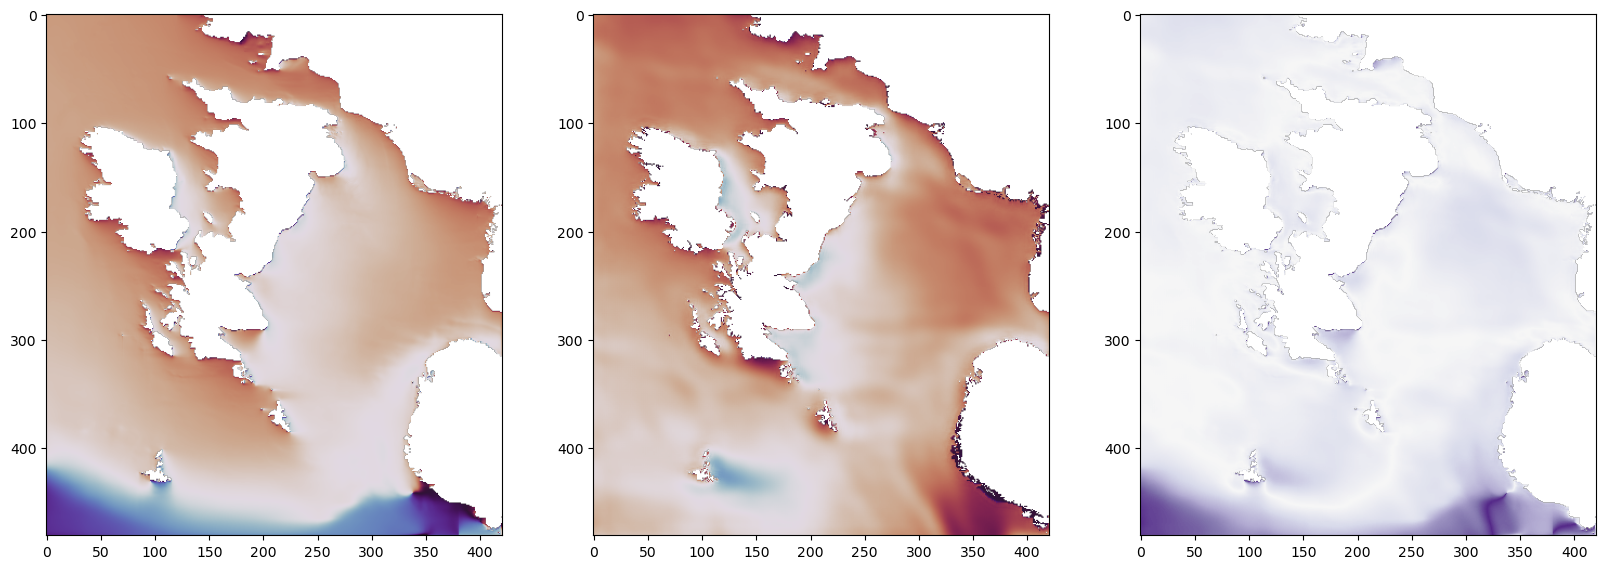

In [67]:
i = 60
theta_true = ens_30_true['theta0'][i]
theta_pred = ens_30_pred['theta0'][i]
theta_error = circular_error(theta_true, theta_pred)

fig, axes = plt.subplots(ncols=3, figsize=(20, 12))
im_true = axes[0].imshow(theta_true, vmin=0, vmax=360, cmap='twilight_shifted')
im_pred = axes[1].imshow(theta_pred, vmin=0, vmax=360, cmap='twilight_shifted')
im_error = axes[2].imshow(theta_error, cmap='PuOr', vmax=np.pi / 5, vmin=-np.pi / 5)
# plt.colorbar(im_true)
# plt.colorbar(im_pred)

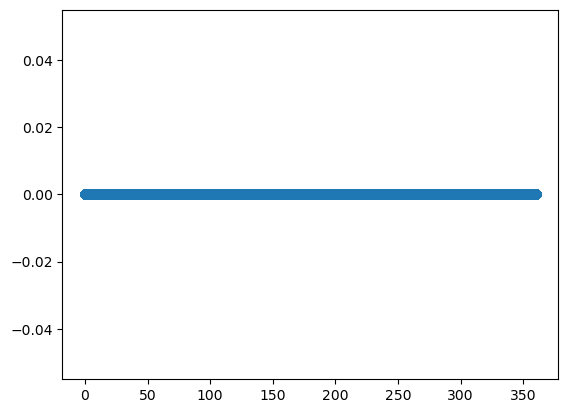

In [24]:
plt.scatter(theta_true.flatten(), theta_pred.flatten())

In [32]:
np.nanmedian(theta_pred) % 360

271.21573638916016

In [27]:
np.nanmedian(theta_true)

273.80963